# Recommendation System
## Adult Census Income

MSalaverri

This project uses census demographic data to build a recommendation system that suggests profile changes likely to increase the probability of earning more than $50K annually.

**Type of Problem**: classification using a *Random Forest model* and later extended with *KNN*, nearest neighbors for recommendations.

In [1]:
# IMPORT LIBRARIES

# Data manipulation & visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn. ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.neighbors import NearestNeighbors
import warnings

import warnings
warnings.filterwarnings('ignore')

In [2]:
# LOADING ORIGINAL DATA
data = "https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv"
df = pd.read_csv(data)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 1. Exploratory Data Analysis

In [3]:
#Dataset dimension
rows, column = df.shape
print("DATASET Dimension:")
print(f'{rows} rows and {column} columns')

DATASET Dimension:
32561 rows and 15 columns


In [4]:
# Get information about range index, number of columns and labels, data types, and the number of cells in each column (non-null values)
print("DATASET General Info:")
df.info()

DATASET General Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
#List Missing values
all_missing_values = df.isnull().sum()
print("Null Values per Column:")
all_missing_values.reset_index()

Null Values per Column:


,index,0
0,age,0
1,workclass,0
2,fnlwgt,0
3,education,0
4,education.num,0
5,marital.status,0
6,occupation,0
7,relationship,0
8,race,0
9,sex,0


In [6]:
num_of_zeros = (df == 0).sum()
print("Count of Zeros per Column:")
num_of_zeros.sort_values(ascending=False).reset_index()

Count of Zeros per Column:


,index,0
0,capital.loss,31042
1,capital.gain,29849
2,age,0
3,education,0
4,education.num,0
5,workclass,0
6,fnlwgt,0
7,occupation,0
8,marital.status,0
9,race,0


### Initial Summary

The dataset contains 32,561 rows and 15 columns, each row representing an individual with demographic and work‑related attributes from the U.S. Census.

Several columns include categorical values such as education, occupation, marital status, and workclass, while others are numeric features like age, capital gain, capital loss, and hours worked per week. No explicit missing values are reported, but some numeric columns (e.g., capital.gain, capital.loss) contain a large number of zeros, which may need to be treated carefully during preprocessing.

The dataset includes:

- 6 integer features (e.g., age, fnlwgt, capital.gain, capital.loss, hours.per.week, education.num)

- 9 categorical features (e.g., workclass, education, marital.status, occupation, relationship, race, sex, native.country, income)

The target variable is **income**, which indicates whether an individual earns <=50K or >50K annually.

## 2. Data Prep

### Duplicates

In [7]:
#Looking for Duplicates
duplicates = df.duplicated()
sum_duplicates = duplicates.sum()

# Verifying Duplicates
print(f"Duplicated Rows: {sum_duplicates}")

print(f"New dimensions after removing duplicates: {df.shape}")

Duplicated Rows: 24
New dimensions after removing duplicates: (32561, 15)


#### RREPLACEMENT OF '?' WITH NaN AND THEN IMPUTATION

In [8]:
df.replace('?', np.nan, inplace=True)

print("Missing values ​​after replacement:")
df.isnull().sum().reset_index()

Missing values ​​after replacement:


,index,0
0,age,0
1,workclass,1836
2,fnlwgt,0
3,education,0
4,education.num,0
5,marital.status,0
6,occupation,1843
7,relationship,0
8,race,0
9,sex,0


In [9]:
# WE ATTRIBUTE THE MISSING TO MODE
cat_cols_missing = ['workclass', 'occupation', 'native.country']

for col in cat_cols_missing:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing after imputation:")
print(df.isnull().sum().sum())

Missing after imputation:
0


## Target Variable

Income


In [10]:
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

X = df.drop('income', axis=1)
y = df['income']


## Outliers


### Key Distributions

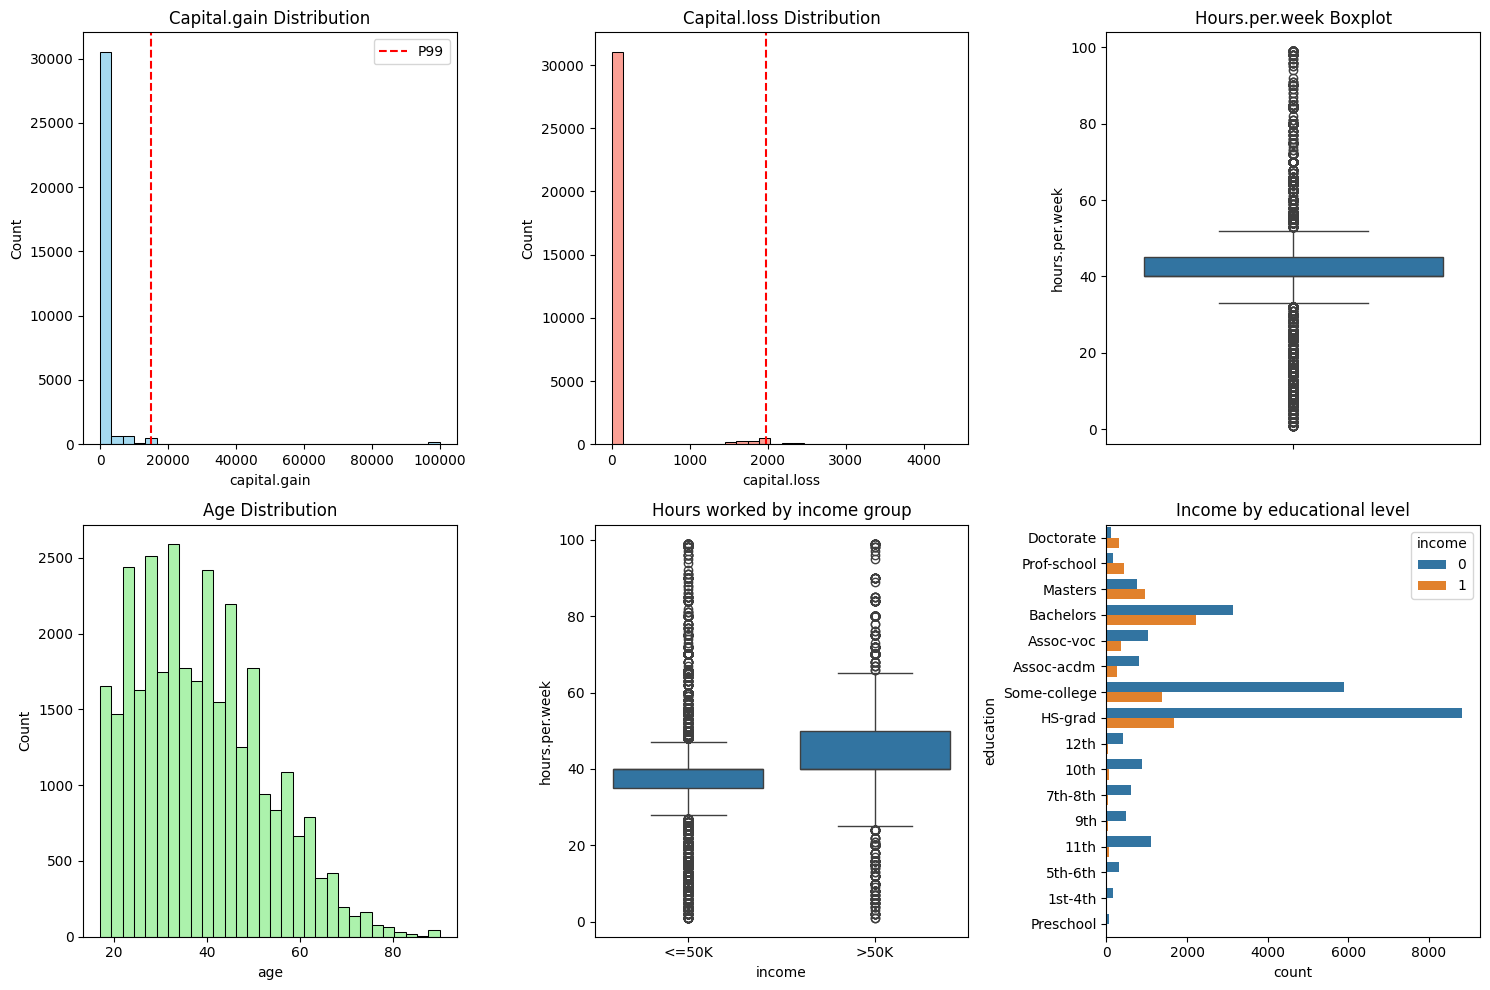

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

#Capital Gain
sns.histplot(data=df, x='capital.gain', bins=30, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Capital.gain Distribution')
axes[0,0].axvline(df['capital.gain'].quantile(0.99), color='red', linestyle='--', label='P99')
axes[0,0].legend()

# Capital loss
sns.histplot(data=df, x='capital.loss', bins=30, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Capital.loss Distribution')
axes[0,1].axvline(df['capital.loss'].quantile(0.99), color='red', linestyle='--')

# Hour per week
sns.boxplot(data=df, y='hours.per.week', ax=axes[0,2])
axes[0,2].set_title('Hours.per.week Boxplot')

# Age
sns.histplot(data=df, x='age', bins=30, ax=axes[1,0], color='lightgreen')
axes[1,0].set_title('Age Distribution')

# Income vs. Hours
sns.boxplot(data=df, x='income', y='hours.per.week', ax=axes[1,1])
axes[1,1].set_title('Hours worked by income group')
axes[1,1].set_xticklabels(['<=50K', '>50K'])

# Incvome vs. Education

edu_order = df.groupby('education')['income'].mean().sort_values(ascending=False).index
sns.countplot(data=df, y='education', hue='income', order=edu_order, ax=axes[1,2])
axes[1,2].set_title('Income by educational level')
plt.tight_layout()
plt.show()

In [12]:
# CATEGORICAL AND NUMERICAL COLUMNS
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include='number').columns

print(f"Categorical ({len(cat_cols)}): {list(cat_cols)}")
print(f"Numeric ({len(num_cols)}): {list(num_cols)}")

Categorical (8): ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Numeric (6): ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


### ENCODING | SCALLING

In [13]:
# ONE-HOT ENCODING FOR CATEGORICAL
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# NUMERIC SCALLING
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X[num_cols])

print("Dimensions after encoding and scaling:", X_encoded.shape)

Dimensions after encoding and scaling: (32561, 97)


### TRAIN AND TEST


In [14]:
# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (26048, 97), Test: (6513, 97)


## Modeling

### Random Forest

In [15]:
# TRAIN
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# PREDICT
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [16]:
# METRICS
print("Accuracy:", rf.score(X_test, y_test))
print("\nAUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8510670965760786

AUC: 0.9014139591630385

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4945
           1       0.73      0.61      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.77      0.78      6513
weighted avg       0.85      0.85      0.85      6513



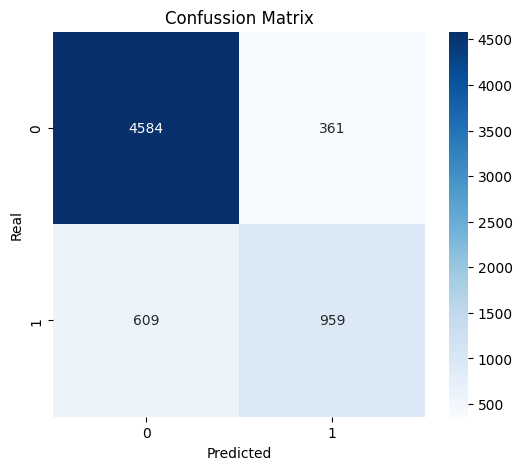

In [17]:
# Confussion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confussion Matrix')
plt.ylabel('Real')
plt.xlabel('Predicted')
plt.show()

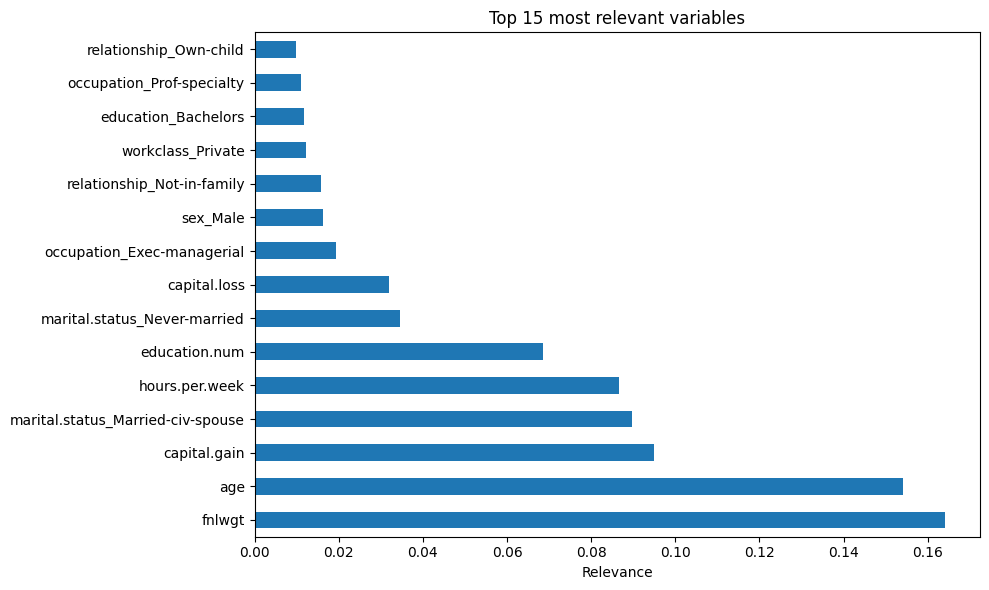

In [18]:
# VARIABLES RELEVANCE
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='barh')
plt.title('Top 15 most relevant variables')
plt.xlabel('Relevance')
plt.tight_layout()
plt.show()

### Content-based recommendation system

For a given user, we look for the most similar profiles earning over $50,000 and see how they differ.
We recommend the most frequent and realistic swaps among these successful neighbors.

In [19]:
# Only Users with income = 1 (success)
X_high = X_encoded[y == 1].copy()
X_high['income'] = 1

# We train KNN on high-income profiles
nn = NearestNeighbors(n_neighbors=10, metric='euclidean')
nn.fit(X_high.drop('income', axis=1, errors='ignore'))

,n_neighbors,10
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'euclidean'
,p,2
,metric_params,None
,n_jobs,None


In [ ]:
# RECOMMENDATION FUNCTION
def recommend_changes(profile_dict, top_n=10):
    # 1. Convert profile to DataFrame
    profile = pd.DataFrame([profile_dict])
    
    # 2. Save original values to show later
    original_values = {
        'education': profile_dict.get('education', '?'),
        'occupation': profile_dict.get('occupation', '?'),
        'marital.status': profile_dict.get('marital.status', '?'),
        'workclass': profile_dict.get('workclass', '?'),
        'hours.per.week': profile_dict.get('hours.per.week', 0)
    }
    
    # 3. Preprocessing exactly as in training
    profile_num = profile[num_cols]
    profile_cat = profile[cat_cols]
    profile_encoded = pd.get_dummies(profile_cat, columns=cat_cols, drop_first=True)
    
    # Align columns with X_encoded
    for col in X_encoded.columns:
        if col not in profile_encoded.columns:
            profile_encoded[col] = 0
    profile_encoded = profile_encoded[X_encoded.columns]
    
    # Scale numeric features
    profile_encoded[num_cols] = scaler.transform(profile_num[num_cols])
    
    # 4. Find nearest neighbors among those earning >50K
    distances, indices = nn.kneighbors(profile_encoded, n_neighbors=top_n)
    neighbors = df.loc[X_high.index[indices[0]]]  # Usando .loc[] para alinear por índice
    
    # 5. Current probability
    current_prob = rf.predict_proba(profile_encoded)[0][1]
    
    print(f"Current probability of earning >50K: {current_prob:.1%}\n")
    print(f"Recommendations based on {top_n} similar people who DO earn >50K:\n")
    
    # 6. Most frequent recommendations
    suggestions = {
        'education': neighbors['education'].mode()[0],
        'occupation': neighbors['occupation'].mode()[0],
        'marital.status': neighbors['marital.status'].mode()[0],
        'workclass': neighbors['workclass'].mode()[0],
        'hours.per.week': int(neighbors['hours.per.week'].median())  # median for hours
    }
    
    changes = []
    for field, suggested in suggestions.items():
        actual = original_values[field]
        if str(actual) != str(suggested):
            changes.append(f"• {field.replace('.', ' ')}: change from '{actual}' → '{suggested}'")
    
    if changes:
        for c in changes:
            print(c)
    else:
        print("You already have a very competitive profile! Small adjustments might be enough.")
    
    return None


In [21]:
profile_1 = {
    'age': 25,
    'workclass': 'Private',
    'fnlwgt': 226000,
    'education': 'HS-grad',
    'education.num': 9,
    'marital.status': 'Never-married',
    'occupation': 'Sales',
    'relationship': 'Own-child',
    'race': 'White',
    'sex': 'Male',
    'capital.gain': 0,
    'capital.loss': 0,
    'hours.per.week': 40,
    'native.country': 'United-States'
}

recommend_changes(profile_1)

Current probability of earning >50K: 2.0%

Recommendations based on 10 similar people who DO earn >50K:

• occupation: change from 'Sales' → 'Adm-clerical'
• marital status: change from 'Never-married' → 'Married-civ-spouse'
• workclass: change from 'Private' → 'Federal-gov'


In [22]:
profile_2 = {
    'age': 35,
    'workclass': 'Private',
    'fnlwgt': 180000,
    'education': 'Some-college',
    'education.num': 10,
    'marital.status': 'Married-civ-spouse',
    'occupation': 'Adm-clerical',
    'relationship': 'Husband',
    'race': 'White',
    'sex': 'Male',
    'capital.gain': 0,
    'capital.loss': 0,
    'hours.per.week': 35,
    'native.country': 'United-States'
}

recommend_changes(profile_2)

Current probability of earning >50K: 4.5%

Recommendations based on 10 similar people who DO earn >50K:

• workclass: change from 'Private' → 'Federal-gov'
• hours per week: change from '35' → '40'
